In [2]:
columns_to_use = [
    'ROUTE_NUMBER',
    'LEAVE_TIME','STOP_TIME'
]

In [4]:
import pandas as pd
file3 = "/Users/kathypresto/Desktop/trimet/Big_Data/untitled folder 3/trimet_stop_event_2023_2024.csv"
df3 = pd.read_csv(file3, usecols=columns_to_use)

In [6]:
df3['YEAR'] = 2023

In [8]:
df3['DELAY_MINUTES'] = (df3['LEAVE_TIME'] - df3['STOP_TIME']) / 60
df3['ON_TIME'] = df3['DELAY_MINUTES'].between(-1, 5)

In [10]:
import pandas as pd
from scipy.stats import chi2_contingency

In [14]:
df_2023 = df3[df3['YEAR'] == 2023]

In [24]:


# Convert ON_TIME to binary (0 = late, 1 = on time)
df_2023['ON_TIME'] = df_2023['ON_TIME'].astype(int)

# Create contingency table: Route vs On-Time Status
contingency = pd.crosstab(df_2023['ROUTE_NUMBER'], df_2023['ON_TIME'])

# Run the Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency)

# Output results
print("Chi-Square Test Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-Value:", p)

# Optional: view the table
print("\nContingency Table 2023:")
print(contingency)


Chi-Square Test Statistic: 3205933.8401762266
Degrees of Freedom: 92
P-Value: 0.0

Contingency Table 2023:
ON_TIME             0        1
ROUTE_NUMBER                  
1               20781    34369
2              564556  1400568
4              636532  2375963
6              623678  1924174
8              526085  1746822
...               ...      ...
291              1312     8110
921           1855782   998407
922             95116    77479
925              6688     5731
992              4502    10982

[93 rows x 2 columns]


In [32]:
# Make a copy of your contingency table
otp_by_route = contingency.copy()

# Create total trips column
otp_by_route['Total'] = otp_by_route[0] + otp_by_route[1]

# Calculate OTP %
otp_by_route['OTP_Percent'] = otp_by_route[1] / otp_by_route['Total'] * 100

# Sort by OTP % (low to high = worst first)
otp_sorted = otp_by_route.sort_values('OTP_Percent')

# Show the bottom 10 routes
print(otp_sorted[['OTP_Percent', 0, 1, 'Total']].head(10))


ON_TIME       OTP_Percent        0       1    Total
ROUTE_NUMBER                                       
921             34.980409  1855782  998407  2854189
922             44.890640    95116   77479   172595
925             46.147033     6688    5731    12419
66              61.525022    22903   36624    59527
98              61.786622    17898   28939    46837
1               62.319130    20781   34369    55150
96              63.350149   107958  186608   294566
99              65.640535    41677   79620   121297
94              69.279250   286173  645357   931530
97              69.772523    13421   30979    44400


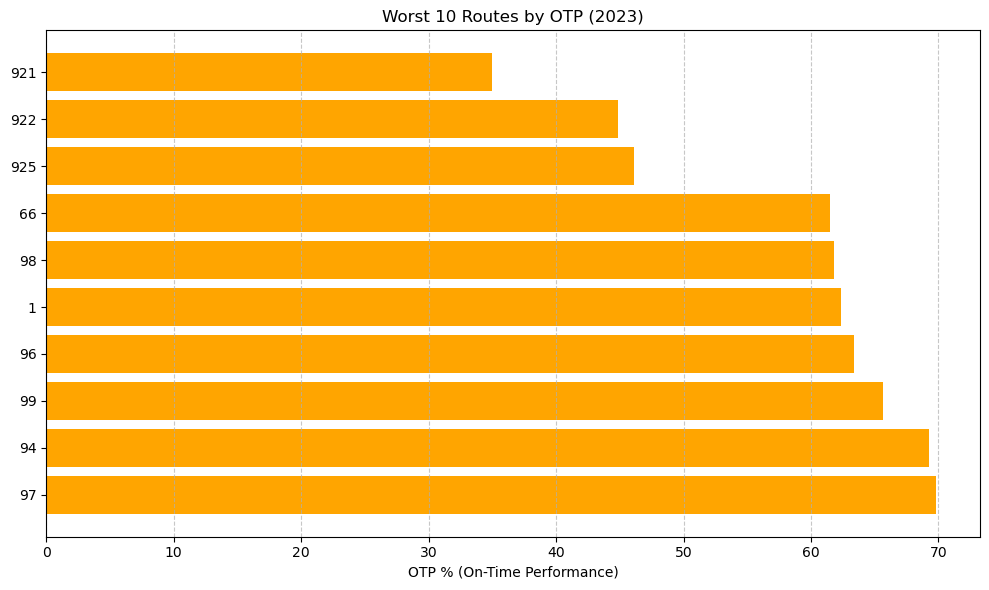

In [20]:
import matplotlib.pyplot as plt

# Take the 10 worst OTP routes
worst_routes = otp_sorted[['OTP_Percent']].head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(worst_routes.index.astype(str), worst_routes['OTP_Percent'], color='orange')
plt.xlabel('OTP % (On-Time Performance)')
plt.title('Worst 10 Routes by OTP (2023)')
plt.gca().invert_yaxis()  # So worst route is at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


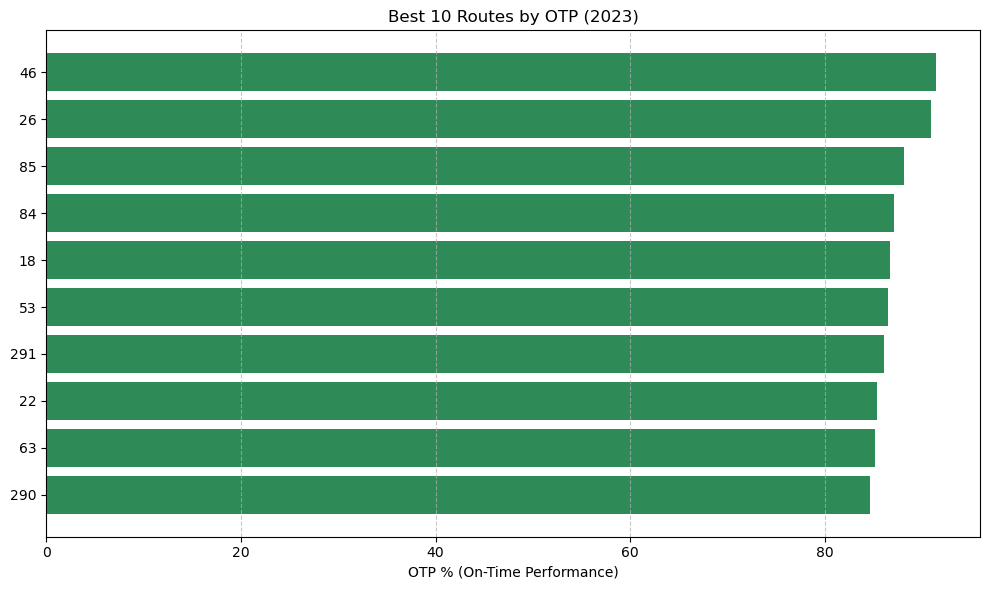

In [22]:
# Take the 10 best OTP routes
best_routes = otp_sorted[['OTP_Percent']].tail(10)
best_routes = best_routes.iloc[::-1]
# Plot
plt.figure(figsize=(10, 6))
plt.barh(best_routes.index.astype(str), best_routes['OTP_Percent'], color='seagreen')
plt.xlabel('OTP % (On-Time Performance)')
plt.title('Best 10 Routes by OTP (2023)')
plt.gca().invert_yaxis()  # So best route is at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [34]:
otp_sorted.to_csv('/Users/kathypresto/Desktop/trimet/Big_Data/Final/chi tests/otp_2023_route-chi-test.csv', index=True)